In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import joblib
import tensorflow as tf
from tensorflow import keras

df = pd.read_csv('../data/ran_kpi_data.csv')

kpis = ['rsrp', 'sinr', 'prb_utilization', 'throughput_mbps', 'packet_loss', 'latency_ms']
X = df[kpis].values
y = df['is_anomaly'].values

# Scale
scaler = joblib.load('../models/scaler.pkl')
X_scaled = scaler.transform(X)

# Train only on normal data — this is key for autoencoders
X_normal = X_scaled[y == 0]
print("Training on normal samples only:", X_normal.shape)

Training on normal samples only: (4750, 6)


c:\Users\manoh\OneDrive\Desktop\PROJECTS\telecom-network-anomaly-detection\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [2]:
input_dim = X_scaled.shape[1]

inputs = keras.Input(shape=(input_dim,))
encoded = keras.layers.Dense(16, activation='relu')(inputs)
encoded = keras.layers.Dense(8, activation='relu')(encoded)
bottleneck = keras.layers.Dense(4, activation='relu')(encoded)
decoded = keras.layers.Dense(8, activation='relu')(bottleneck)
decoded = keras.layers.Dense(16, activation='relu')(decoded)
outputs = keras.layers.Dense(input_dim, activation='linear')(decoded)

autoencoder = keras.Model(inputs, outputs)
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 6)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 570 (2.23 KB)

 Trainable params: 570 (2.23 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.5019 - val_loss: 0.3940
Epoch 2/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3426 - val_loss: 0.2916
Epoch 3/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2434 - val_loss: 0.1961
Epoch 4/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1915 - val_loss: 0.1586
Epoch 5/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1099 - val_loss: 0.0698
Epoch 6/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0608 - val_loss: 0.0569
Epoch 7/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0521 - val_loss: 0.0527
Epoch 8/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0478 - val_loss: 0.0486
Epoch 9/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0458 - val_loss: 0.0472
Epoch 10/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0439 - val_loss: 0.0468
Epoch 11/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0429 - val_loss: 0.0461
Epoch 12/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

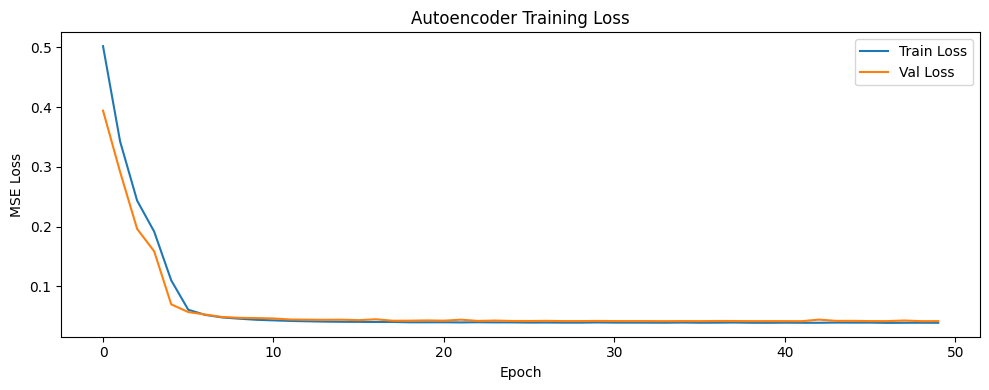

In [3]:
history = autoencoder.fit(
    X_normal, X_normal,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Autoencoder Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.tight_layout()
plt.show()

In [4]:
X_reconstructed = autoencoder.predict(X_scaled)
reconstruction_errors = np.mean(np.power(X_scaled - X_reconstructed, 2), axis=1)

# Set threshold at 95th percentile of normal data errors
normal_errors = reconstruction_errors[y == 0]
threshold = np.percentile(normal_errors, 95)
print(f"Threshold: {threshold:.4f}")

preds_ae = (reconstruction_errors > threshold).astype(int)
print(f"Anomalies detected: {preds_ae.sum()}")

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Threshold: 0.1337
Anomalies detected: 410


              precision    recall  f1-score   support

      Normal       0.98      0.95      0.97      4750
     Anomaly       0.42      0.69      0.52       250

    accuracy                           0.94      5000
   macro avg       0.70      0.82      0.74      5000
weighted avg       0.95      0.94      0.94      5000



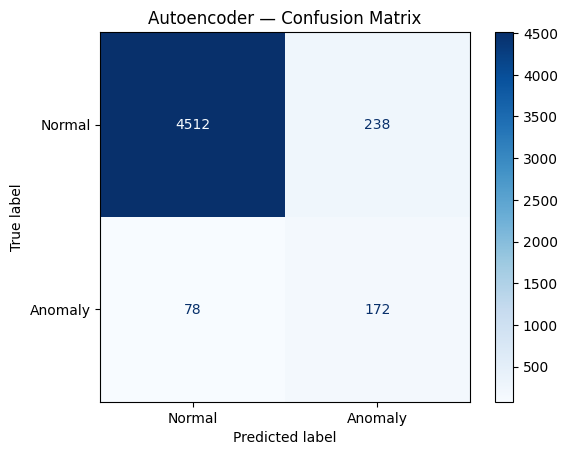

In [5]:
print(classification_report(y, preds_ae, target_names=['Normal', 'Anomaly']))

cm = confusion_matrix(y, preds_ae)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Anomaly'])
disp.plot(cmap='Blues')
plt.title('Autoencoder — Confusion Matrix')
plt.show()

In [6]:
autoencoder.save('../models/autoencoder.keras')
np.save('../models/ae_threshold.npy', threshold)
print("Autoencoder saved")

Autoencoder saved
